In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from collections import defaultdict

In [18]:
def load_mooncake_data(input_file):
    data = []
    with open(input_file, 'r') as f:
        for line in f:
            data.append(json.loads(line.strip()))

    # Convert to DataFrame for easier analysis
    df = pd.DataFrame(data)

    # Convert timestamp from milliseconds to seconds
    df['timestamp_seconds'] = df['timestamp'] / 1000

    print(f"Dataset info:")
    print(f"Total requests: {len(df)}")
    print(f"Time range: {df['timestamp_seconds'].min():.1f}s to {df['timestamp_seconds'].max():.1f}s")
    print(f"Duration: {(df['timestamp_seconds'].max() - df['timestamp_seconds'].min())/60:.1f} minutes")
    print(f"Input length range: {df['input_length'].min()} to {df['input_length'].max()}")
    print(f"Output length range: {df['output_length'].min()} to {df['output_length'].max()}")

    # Create distribution plots
    fig, axes = plt.subplots(2, 2, figsize=(10, 6))
    workload_name = input_file.split('/')[-1].split('.')[0]
    fig.suptitle(f'{workload_name} - Distribution Analysis', fontsize=16)

    # 1. RPS calculation and distribution
    # Group by second and count requests
    rps_data = df.groupby(df['timestamp_seconds'].astype(int)).size()
    print(f"RPS stats: min={rps_data.min()}, max={rps_data.max()}, mean={rps_data.mean():.2f}, std={rps_data.std():.2f}")

    # RPS distribution
    axes[0, 0].hist(rps_data.values, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0, 0].set_xlabel('Requests per Second')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('RPS Distribution')
    axes[0, 0].grid(True, alpha=0.3)

    # 2. Input token length distribution
    axes[0, 1].hist(df['input_length'], bins=50, alpha=0.7, color='lightgreen', edgecolor='black')
    axes[0, 1].set_xlabel('Input Token Length')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('Input Token Length Distribution')
    axes[0, 1].grid(True, alpha=0.3)

    # 3. Output token length distribution
    axes[1, 0].hist(df['output_length'], bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
    axes[1, 0].set_xlabel('Output Token Length')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title('Output Token Length Distribution')
    axes[1, 0].grid(True, alpha=0.3)

    # 4. Scatter plot of input vs output length
    scatter = axes[1, 1].scatter(df['input_length'], df['output_length'], alpha=0.5, s=20, c='purple')
    axes[1, 1].set_xlabel('Input Token Length')
    axes[1, 1].set_ylabel('Output Token Length')
    axes[1, 1].set_title('Input vs Output Token Length')
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    

    # Print some statistics
    print(f"\nInput token stats: min={df['input_length'].min()}, max={df['input_length'].max()}, mean={df['input_length'].mean():.1f}, std={df['input_length'].std():.1f}")
    print(f"Output token stats: min={df['output_length'].min()}, max={df['output_length'].max()}, mean={df['output_length'].mean():.1f}, std={df['output_length'].std():.1f}")


    ####################################################################################################################################################################################
    ####################################################################################################################################################################################
    ####################################################################################################################################################################################
    
    # Create time series plots (1 second granularity) and token block distribution
    fig, axes = plt.subplots(3, 2, figsize=(10, 6))
    fig.suptitle(f'{workload_name} - Time Series Analysis (1 second granularity)', fontsize=16)

    # Calculate number of token blocks per request (each token block = 500 tokens)
    df['num_token_blocks'] = df['hash_ids'].apply(len)
    df['estimated_input_tokens_from_blocks'] = df['num_token_blocks'] * 500

    # Prepare time series data
    max_time = int(df['timestamp_seconds'].max()) + 1
    time_bins = range(0, max_time + 1)

    # 1. RPS over time
    rps_by_second = df.groupby(df['timestamp_seconds'].astype(int)).size().reindex(time_bins, fill_value=0)

    axes[0, 0].plot(rps_by_second.index, rps_by_second.values, linewidth=1, alpha=0.8, color='blue')
    axes[0, 0].set_xlabel('Time (seconds)')
    axes[0, 0].set_ylabel('Requests per Second')
    axes[0, 0].set_title('RPS Over Time')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].set_xlim(0, max_time)

    # 2. Average input token length over time
    input_tokens_by_second = df.groupby(df['timestamp_seconds'].astype(int))['input_length'].mean().reindex(time_bins, fill_value=np.nan)

    # Only plot points where we have data (non-NaN values)
    valid_input_mask = ~input_tokens_by_second.isna()
    axes[0, 1].plot(input_tokens_by_second.index[valid_input_mask], input_tokens_by_second.values[valid_input_mask], linewidth=1, alpha=0.8, color='green')
    axes[0, 1].set_xlabel('Time (seconds)')
    axes[0, 1].set_ylabel('Average Input Token Length')
    axes[0, 1].set_title('Average Input Token Length Over Time')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_xlim(0, max_time)

    # 3. Average output token length over time
    output_tokens_by_second = df.groupby(df['timestamp_seconds'].astype(int))['output_length'].mean().reindex(time_bins, fill_value=np.nan)

    # Only plot points where we have data (non-NaN values)
    valid_output_mask = ~output_tokens_by_second.isna()
    axes[1, 0].plot(output_tokens_by_second.index[valid_output_mask], output_tokens_by_second.values[valid_output_mask], linewidth=1, alpha=0.8, color='red')
    axes[1, 0].set_xlabel('Time (seconds)')
    axes[1, 0].set_ylabel('Average Output Token Length')
    axes[1, 0].set_title('Average Output Token Length Over Time')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_xlim(0, max_time)

    # 4. Prefix sharing ratio over time (1-minute windows with radix tree approach)
    def calculate_prefix_sharing_ratio(requests_with_timestamps):
        """
        Calculate prefix sharing ratio using radix tree approach for LLM prefix caching.
        
        Within each 1-minute window, each request can reuse KV cache from the longest 
        matching prefix among requests that arrived EARLIER in the same window.
        
        Args:
            requests_with_timestamps: List of (timestamp, hash_ids) tuples, sorted by timestamp
        """
        if len(requests_with_timestamps) <= 1:
            return 0.0
        
        def find_longest_common_prefix(seq1, seq2):
            """Find the length of longest common prefix between two sequences"""
            min_len = min(len(seq1), len(seq2))
            for i in range(min_len):
                if seq1[i] != seq2[i]:
                    return i
            return min_len
        
        sharing_ratios = []
        
        for i, (current_timestamp, current_hash_ids) in enumerate(requests_with_timestamps):
            if len(current_hash_ids) == 0:
                continue
            
            max_prefix_length = 0
            
            # Find the longest matching prefix among requests that arrived EARLIER in this window
            for j in range(i):  # Only compare with earlier requests in the same window
                prev_timestamp, prev_hash_ids = requests_with_timestamps[j]
                prefix_length = find_longest_common_prefix(current_hash_ids, prev_hash_ids)
                max_prefix_length = max(max_prefix_length, prefix_length)
            
            # Calculate sharing ratio
            sharing_ratio = max_prefix_length / len(current_hash_ids) if len(current_hash_ids) > 0 else 0.0
            sharing_ratios.append(sharing_ratio)
        
        # Return average sharing ratio across all requests in this time window
        return sum(sharing_ratios) / len(sharing_ratios) if sharing_ratios else 0.0

    # Calculate prefix sharing ratio per minute
    max_minute = int(df['timestamp_seconds'].max() / 60) + 1
    minute_bins = range(0, max_minute + 1)

    prefix_ratios_by_minute = []
    minute_timestamps = []

    for minute in minute_bins:
        # Get all requests in this minute
        minute_data = df[(df['timestamp_seconds'] >= minute * 60) & (df['timestamp_seconds'] < (minute + 1) * 60)]
        if len(minute_data) > 1:  # Need at least 2 requests to calculate sharing
            # Sort by timestamp and create list of (timestamp, hash_ids) tuples
            minute_data_sorted = minute_data.sort_values('timestamp_seconds')
            requests_with_timestamps = list(zip(minute_data_sorted['timestamp_seconds'], minute_data_sorted['hash_ids']))
            ratio = calculate_prefix_sharing_ratio(requests_with_timestamps)
            prefix_ratios_by_minute.append(ratio)
            minute_timestamps.append(minute)

    axes[1, 1].plot(minute_timestamps, prefix_ratios_by_minute, linewidth=2, alpha=0.8, color='purple', marker='o', markersize=4)
    axes[1, 1].set_xlabel('Time (minutes)')
    axes[1, 1].set_ylabel('Prefix Sharing Ratio')
    axes[1, 1].set_title('Prefix Cache Hit Ratio Over Time (1-minute windows)')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].set_xlim(0, max_minute)
    axes[1, 1].set_ylim(0, 1)

    # 5. Token blocks per request distribution
    axes[2, 0].hist(df['num_token_blocks'], bins=30, alpha=0.7, color='orange', edgecolor='black')
    axes[2, 0].set_xlabel('Number of Token Blocks')
    axes[2, 0].set_ylabel('Frequency')
    axes[2, 0].set_title('Token Blocks per Request Distribution')
    axes[2, 0].grid(True, alpha=0.3)

    # Hide the empty subplot
    axes[2, 1].set_visible(False)

    plt.tight_layout()
    plt.show()

    # Print time series statistics
    print(f"Time series stats:")
    print(f"RPS: min={rps_by_second.min()}, max={rps_by_second.max()}, mean={rps_by_second.mean():.2f}")
    print(f"Avg Input tokens: min={input_tokens_by_second.min():.1f}, max={input_tokens_by_second.max():.1f}, mean={input_tokens_by_second.mean():.1f}")
    print(f"Avg Output tokens: min={output_tokens_by_second.min():.1f}, max={output_tokens_by_second.max():.1f}, mean={output_tokens_by_second.mean():.1f}")
    print(f"Prefix sharing ratio: min={min(prefix_ratios_by_minute) if prefix_ratios_by_minute else 0:.3f}, max={max(prefix_ratios_by_minute) if prefix_ratios_by_minute else 0:.3f}, mean={np.mean(prefix_ratios_by_minute) if prefix_ratios_by_minute else 0:.3f}")
    print(f"Token blocks per request: min={df['num_token_blocks'].min()}, max={df['num_token_blocks'].max()}, mean={df['num_token_blocks'].mean():.1f}")
    print(f"Data coverage: {valid_input_mask.sum()} out of {len(time_bins)} seconds have input data, {valid_output_mask.sum()} have output data")
    print(f"Prefix sharing data: {len(prefix_ratios_by_minute)} minutes have prefix sharing data out of {max_minute} total minutes")
    
    
    ####################################################################################################################################################################################
    ####################################################################################################################################################################################
    ####################################################################################################################################################################################
    
    
    # Additional analysis: Token blocks and sharing patterns
    fig, axes = plt.subplots(2, 2, figsize=(10, 6))
    fig.suptitle(f'{workload_name} - Token Block Analysis', fontsize=16)

    # 1. Comparison of actual input length vs estimated from blocks
    axes[0, 0].scatter(df['estimated_input_tokens_from_blocks'], df['input_length'], alpha=0.5, s=20)
    axes[0, 0].plot([0, df['estimated_input_tokens_from_blocks'].max()], [0, df['estimated_input_tokens_from_blocks'].max()], 'r--', alpha=0.8, label='Perfect match')
    axes[0, 0].set_xlabel('Estimated Input Tokens (from blocks)')
    axes[0, 0].set_ylabel('Actual Input Length')
    axes[0, 0].set_title('Actual vs Estimated Input Length')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # 2. Token block sharing analysis - count unique hash_ids
    all_hash_ids = []
    for hash_list in df['hash_ids']:
        all_hash_ids.extend(hash_list)

    from collections import Counter
    hash_id_counts = Counter(all_hash_ids)
    sharing_counts = list(hash_id_counts.values())

    axes[0, 1].hist(sharing_counts, bins=50, alpha=0.7, color='purple', edgecolor='black')
    axes[0, 1].set_xlabel('Number of Times Token Block is Used')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('Token Block Reuse Distribution')
    axes[0, 1].set_yscale('log')
    axes[0, 1].grid(True, alpha=0.3)

    # 3. Timeline of unique token blocks used
    df_sorted = df.sort_values('timestamp_seconds')
    cumulative_unique_blocks = []
    seen_blocks = set()

    for _, row in df_sorted.iterrows():
        seen_blocks.update(row['hash_ids'])
        cumulative_unique_blocks.append(len(seen_blocks))

    axes[1, 0].plot(df_sorted['timestamp_seconds'], cumulative_unique_blocks, linewidth=2, color='darkgreen')
    axes[1, 0].set_xlabel('Time (seconds)')
    axes[1, 0].set_ylabel('Cumulative Unique Token Blocks')
    axes[1, 0].set_title('Cumulative Unique Token Blocks Over Time')
    axes[1, 0].grid(True, alpha=0.3)

    # Hide the empty subplot
    axes[1, 1].set_visible(False)

    plt.tight_layout()
    plt.show()

    # Print token block statistics
    print(f"\nToken block statistics:")
    print(f"Total unique token blocks: {len(hash_id_counts)}")
    print(f"Most reused block used {max(sharing_counts)} times")
    print(f"Average token blocks per request: {df['num_token_blocks'].mean():.1f}")
    print(f"Token blocks range: {df['num_token_blocks'].min()} to {df['num_token_blocks'].max()}")
    print(f"Block 0 (common prefix) used {hash_id_counts[0]} times out of {len(df)} requests ({hash_id_counts[0]/len(df)*100:.1f}%)")

    print(f"\nPrefix sharing statistics:")
    print(f"Average prefix sharing ratio: {np.mean(prefix_ratios_by_minute):.3f}")
    print(f"Min prefix sharing ratio: {np.min(prefix_ratios_by_minute):.3f}")
    print(f"Max prefix sharing ratio: {np.max(prefix_ratios_by_minute):.3f}")
    print(f"Std prefix sharing ratio: {np.std(prefix_ratios_by_minute):.3f}")



Dataset info:
Total requests: 12031
Time range: 0.0s to 3537.0s
Duration: 58.9 minutes
Input length range: 891 to 126195
Output length range: 1 to 2000
RPS stats: min=2, max=28, mean=10.20, std=3.35


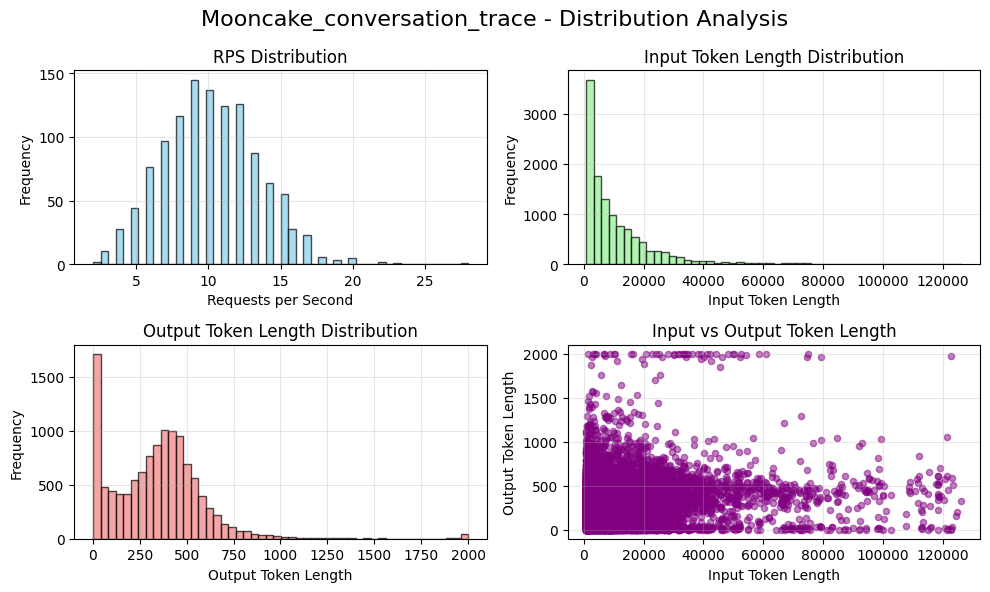


Input token stats: min=891, max=126195, mean=12035.1, std=15801.0
Output token stats: min=1, max=2000, mean=342.6, std=249.9


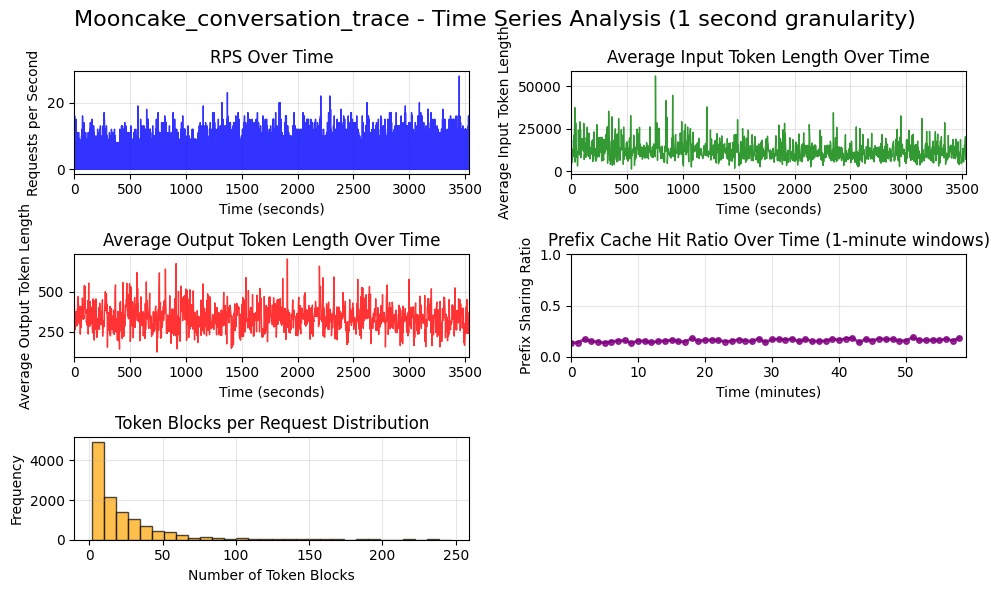

Time series stats:
RPS: min=0, max=28, mean=3.40
Avg Input tokens: min=1236.0, max=55944.7, mean=12090.5
Avg Output tokens: min=123.7, max=705.2, mean=339.6
Prefix sharing ratio: min=0.133, max=0.188, mean=0.159
Token blocks per request: min=2, max=247, mean=24.0
Data coverage: 1180 out of 3538 seconds have input data, 1180 have output data
Prefix sharing data: 59 minutes have prefix sharing data out of 59 total minutes


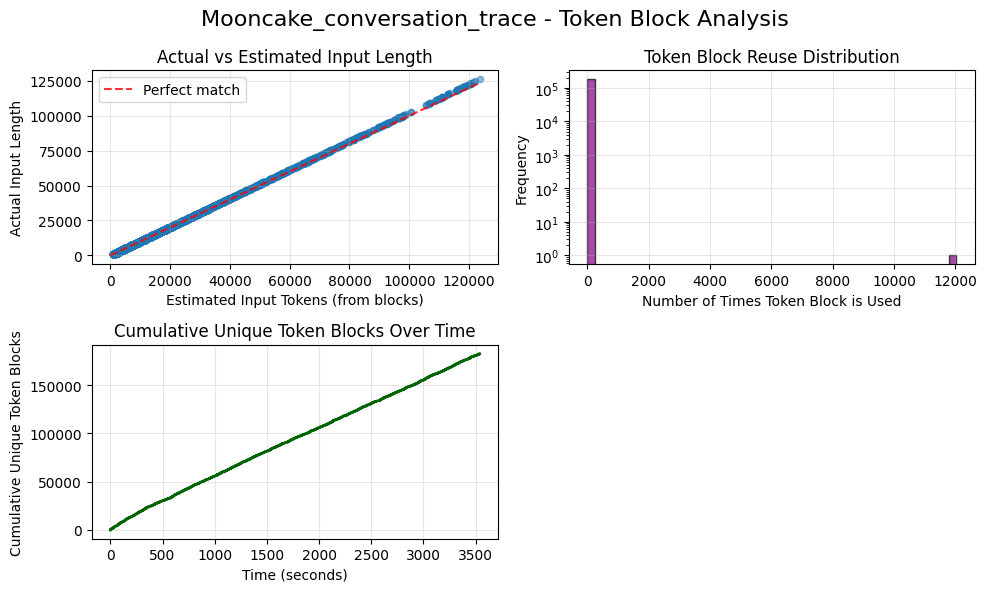


Token block statistics:
Total unique token blocks: 182790
Most reused block used 12031 times
Average token blocks per request: 24.0
Token blocks range: 2 to 247
Block 0 (common prefix) used 12031 times out of 12031 requests (100.0%)

Prefix sharing statistics:
Average prefix sharing ratio: 0.159
Min prefix sharing ratio: 0.133
Max prefix sharing ratio: 0.188
Std prefix sharing ratio: 0.013
Dataset info:
Total requests: 23608
Time range: 0.0s to 3537.0s
Duration: 58.9 minutes
Input length range: 891 to 126195
Output length range: 1 to 2000
RPS stats: min=5, max=47, mean=20.01, std=5.61


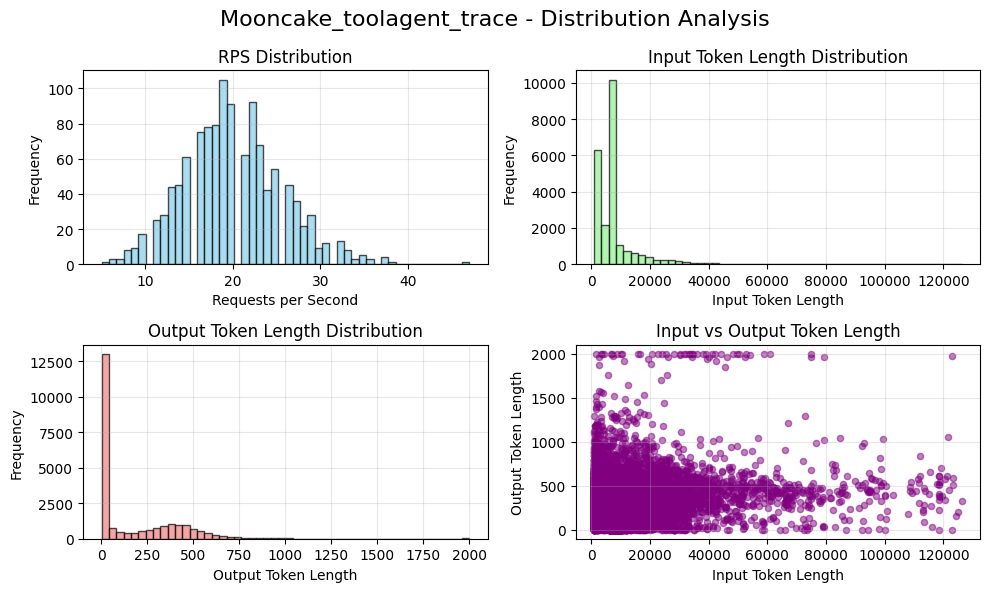


Input token stats: min=891, max=126195, mean=8596.2, std=11003.0
Output token stats: min=1, max=2000, mean=182.1, std=242.3


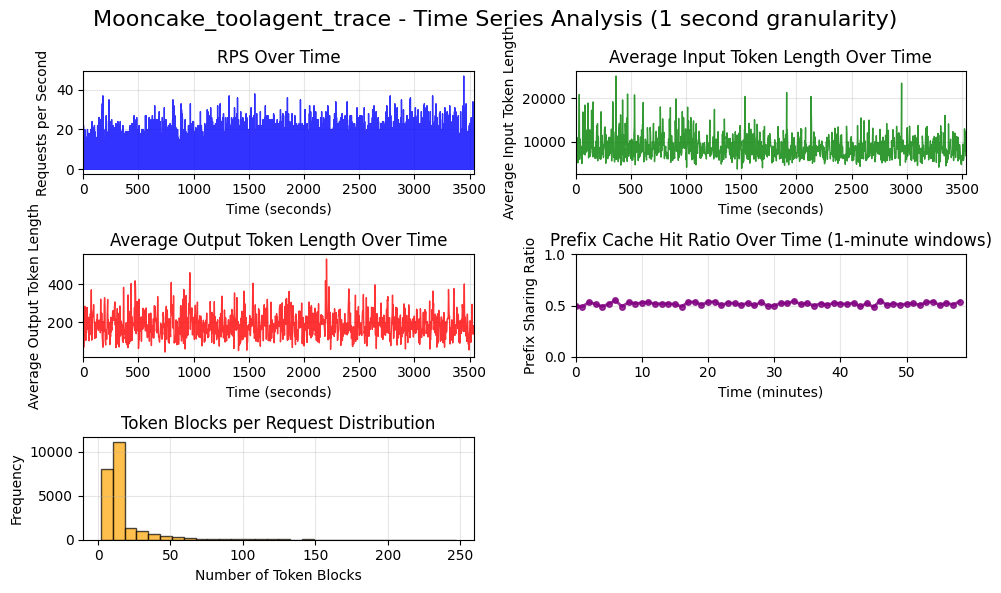

Time series stats:
RPS: min=0, max=47, mean=6.67
Avg Input tokens: min=3651.5, max=25131.3, mean=8675.1
Avg Output tokens: min=41.2, max=534.2, mean=185.5
Prefix sharing ratio: min=0.484, max=0.550, mean=0.517
Token blocks per request: min=2, max=247, mean=17.4
Data coverage: 1180 out of 3538 seconds have input data, 1180 have output data
Prefix sharing data: 59 minutes have prefix sharing data out of 59 total minutes


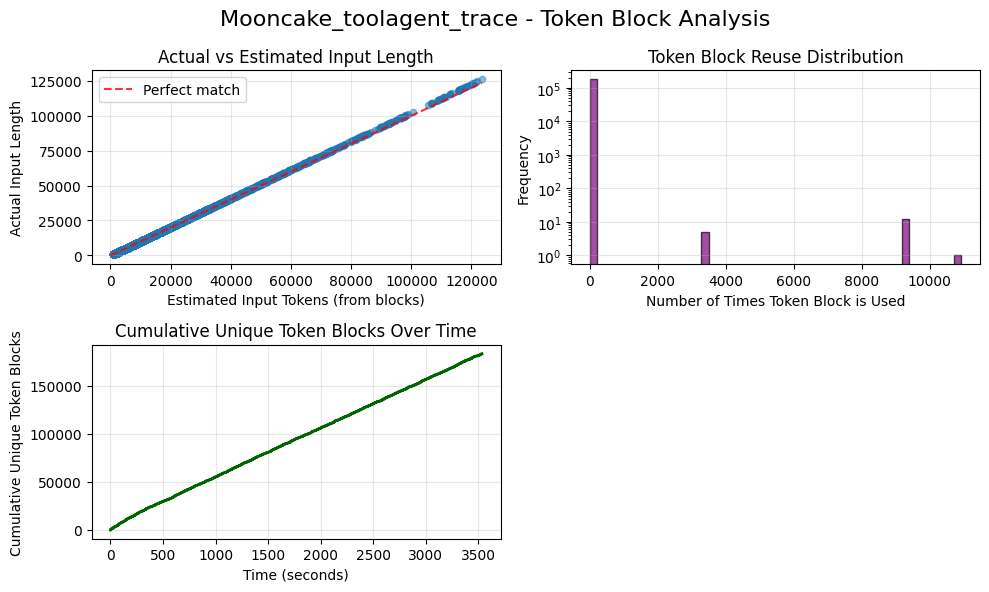


Token block statistics:
Total unique token blocks: 183300
Most reused block used 10938 times
Average token blocks per request: 17.4
Token blocks range: 2 to 247
Block 0 (common prefix) used 10938 times out of 23608 requests (46.3%)

Prefix sharing statistics:
Average prefix sharing ratio: 0.517
Min prefix sharing ratio: 0.484
Max prefix sharing ratio: 0.550
Std prefix sharing ratio: 0.016
Dataset info:
Total requests: 3993
Time range: 0.0s to 1022.0s
Duration: 17.0 minutes
Input length range: 13 to 191378
Output length range: 1 to 893
RPS stats: min=1, max=13, mean=4.02, std=1.98


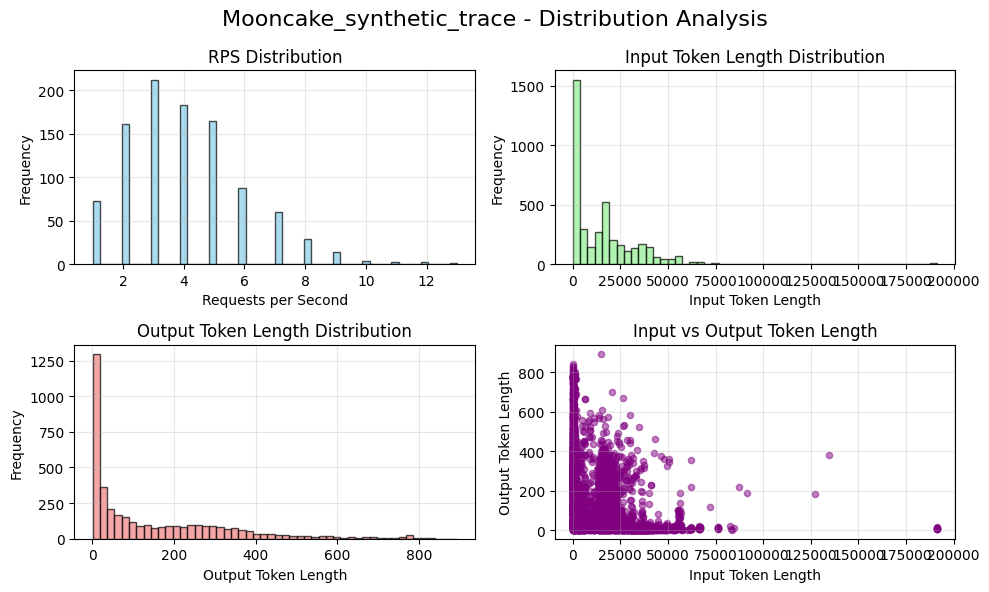


Input token stats: min=13, max=191378, mean=15325.5, std=18382.5
Output token stats: min=1, max=893, mean=149.1, std=178.2


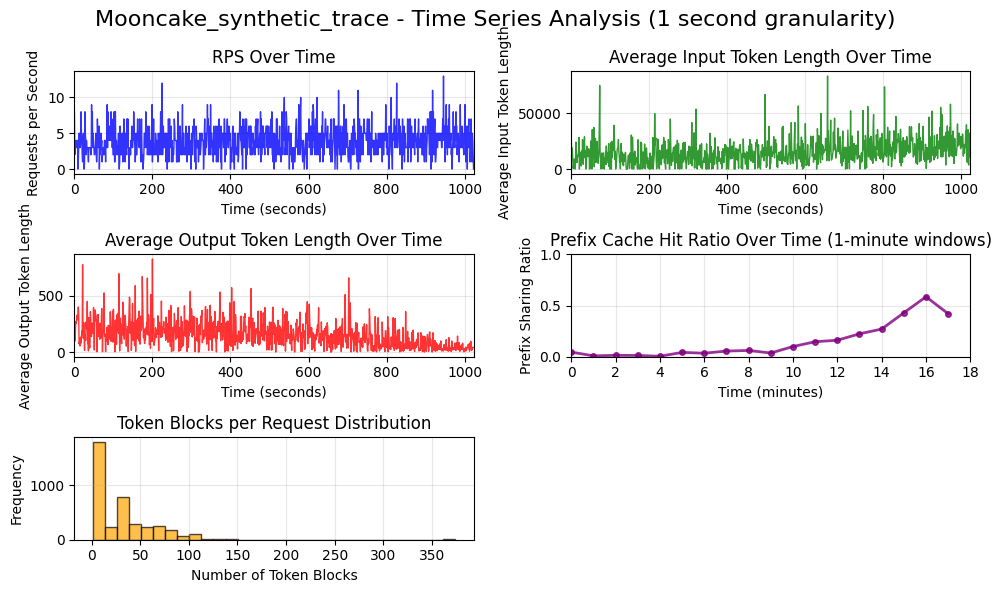

Time series stats:
RPS: min=0, max=13, mean=3.90
Avg Input tokens: min=16.5, max=83403.0, mean=15372.7
Avg Output tokens: min=2.0, max=825.0, mean=153.9
Prefix sharing ratio: min=0.004, max=0.585, mean=0.147
Token blocks per request: min=1, max=374, mean=30.5
Data coverage: 993 out of 1024 seconds have input data, 993 have output data
Prefix sharing data: 18 minutes have prefix sharing data out of 18 total minutes


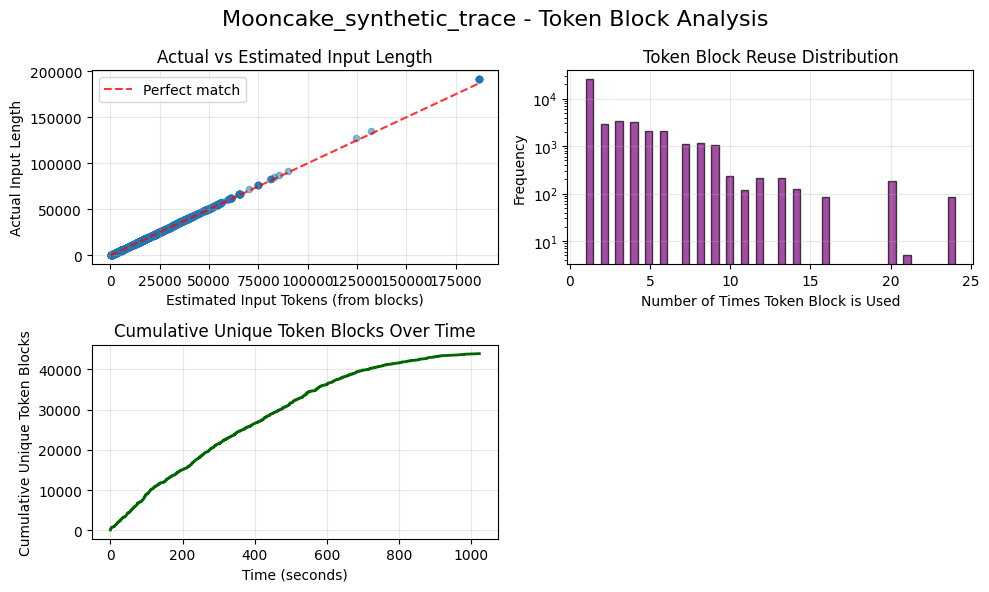


Token block statistics:
Total unique token blocks: 43924
Most reused block used 24 times
Average token blocks per request: 30.5
Token blocks range: 1 to 374
Block 0 (common prefix) used 1 times out of 3993 requests (0.0%)

Prefix sharing statistics:
Average prefix sharing ratio: 0.147
Min prefix sharing ratio: 0.004
Max prefix sharing ratio: 0.585
Std prefix sharing ratio: 0.168


In [19]:
load_mooncake_data('input_trace/Mooncake_conversation_trace.jsonl')
load_mooncake_data('input_trace/Mooncake_toolagent_trace.jsonl')
load_mooncake_data('input_trace/Mooncake_synthetic_trace.jsonl')